# 01 — Titanic EDA: profiling, cleaning and the data story

**Module:** `/analytics` · **Notebook 1 of 2** · Zepto Data & AI Platform capstone

This notebook is the **only** place the raw dataset is loaded (`sns.load_dataset('titanic')`).
Immediately after loading it is saved to `titanic.csv`, which is the committed offline fallback and the
input for `02_modeling.ipynb`. Row-level cleaning rules live in `titanic_utils.py` so both notebooks
apply exactly the same logic.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from titanic_utils import (RAW_CSV, SURVIVAL_PALETTE, COLOR_SURVIVED, COLOR_DIED, COLOR_THIRD,
                           missing_report, strategy_for, drop_sparse_rows, add_deck_category)

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
pd.set_option("display.width", 140)

## Task 1 — Load once, save the offline fallback, profile

In [2]:
# The one and only load of the raw dataset. If the network is unavailable, fall back to the committed CSV.
try:
    df_raw = sns.load_dataset("titanic")
    df_raw.to_csv(RAW_CSV, index=False)          # committed offline fallback
    print("Loaded via sns.load_dataset('titanic') and saved ->", RAW_CSV)
except Exception as exc:                          # grading machine without internet
    df_raw = pd.read_csv(RAW_CSV)
    print(f"Network load failed ({type(exc).__name__}); read committed {RAW_CSV} instead")

print("shape:", df_raw.shape)

Loaded via sns.load_dataset('titanic') and saved -> titanic.csv
shape: (891, 15)


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df_raw.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df_raw.describe(include=['object', 'category', 'bool'])

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


In [6]:
miss = missing_report(df_raw)
miss["strategy (threshold rule)"] = miss["missing_pct"].apply(strategy_for)
miss

,missing_count,missing_pct,strategy (threshold rule)
deck,688,77.22,too sparse to impute (>30%) -> encode 'Missing...
age,177,19.87,impute (5%-30% missing)
embarked,2,0.22,drop rows (<5% missing)
embark_town,2,0.22,drop rows (<5% missing)


In [7]:
balance = df_raw["survived"].value_counts().rename({0: "died (0)", 1: "survived (1)"})
print(pd.DataFrame({"count": balance, "pct": (balance / len(df_raw) * 100).round(2)}))

              count    pct
survived                  
died (0)        549  61.62
survived (1)    342  38.38


### Missing values measured, and the strategy each one gets

| Column | Missing | % missing | Rule that applies | Decision |
|---|---|---|---|---|
| `embarked` | 2 | **0.22%** | < 5% → drop rows | Drop the 2 rows. |
| `embark_town` | 2 | **0.22%** | < 5% → drop rows | Same 2 passengers as `embarked` (it is the spelled-out port), so the same 2-row drop fixes both. |
| `age` | 177 | **19.87%** | 5%–30% → impute | Impute with the **median age of the passenger's (sex, pclass) group**. |
| `deck` | 688 | **77.22%** | > 30% → too sparse to impute | Keep the column, encode missing as its **own category `"Missing"`** (justified below). |

**Class balance:** 549 died (61.62%) vs 342 survived (38.38%), about 1.6 : 1. That is a moderate imbalance. It matters later for the stratified split and for the imbalance-handling comparison in `02_modeling.ipynb`.

**Why a group median for `age` and not a global one?** Age differs a lot by class and sex. In the table below the medians range from 21.5 (3rd-class women) to 40 (1st-class men). A single global median (28) would push every missing 1st-class man about 12 years too young. Median beats mean because age is slightly right-skewed.

## Task 2 — Apply the missing-value strategy per column

In [8]:
df = drop_sparse_rows(df_raw)                     # embarked / embark_town: 0.22% -> drop 2 rows
print("rows after dropping embarked-missing rows:", len(df), f"(dropped {len(df_raw) - len(df)})")

# age: 19.87% -> impute. Median of the passenger's (sex, pclass) group, because age differs a lot
# between e.g. 1st-class women and 3rd-class men; a single global median would blur that.
group_median = df.groupby(["sex", "pclass"])["age"].transform("median")
print("\nMedian age used per (sex, pclass) group:")
print(df.groupby(["sex", "pclass"])["age"].median().unstack())
df["age"] = df["age"].fillna(group_median)

# deck: 77.22% -> too sparse to impute; keep as its own 'Missing' category (see reasoning below)
df = add_deck_category(df)

print("\nRemaining missing values per column:")
print(df.isna().sum()[lambda s: s > 0] if df.isna().sum().sum() else "none")
print("clean shape:", df.shape)

rows after dropping embarked-missing rows: 889 (dropped 2)

Median age used per (sex, pclass) group:
pclass     1     2     3
sex                     
female  35.0  28.0  21.5
male    40.0  30.0  25.0

Remaining missing values per column:
none
clean shape: (889, 15)


In [9]:
# Evidence for keeping deck as a 'Missing' category rather than dropping it:
print(pd.crosstab(df["deck"] == "Missing", df["pclass"], normalize="columns").round(3)
        .rename(index={True: "deck missing", False: "deck known"}))
print("\nSurvival rate: deck known = {:.3f}, deck missing = {:.3f}".format(
    df.loc[df.deck != "Missing", "survived"].mean(), df.loc[df.deck == "Missing", "survived"].mean()))

pclass            1      2      3
deck                             
deck known    0.808  0.087  0.024
deck missing  0.192  0.913  0.976

Survival rate: deck known = 0.667, deck missing = 0.299


**Why `deck` becomes a `"Missing"` category instead of being dropped or imputed.** At 77.22% missing, any imputed deck would mostly be invented. But the missingness is *not random*, and that is itself information:
- Deck is known for 80.8% of 1st-class passengers but only 8.7% of 2nd-class and 2.4% of 3rd-class passengers. Cabin records mostly survived for the wealthy.
- Passengers with a recorded deck survived at **66.7%**, against **29.9%** for those without one.

Dropping the column would throw that signal away. Imputing would destroy it by making "unknown" look like a real deck. An explicit `"Missing"` level keeps the signal honestly. (In `02_modeling.ipynb` I leave `deck` out of the features anyway. The deck-known/unknown split is almost a copy of `pclass`, so it adds little beyond class. That trade-off is stated there.)

After cleaning: **889 rows × 15 columns, zero missing values.**

## Task 3 — Univariate analysis: `age` and `fare`

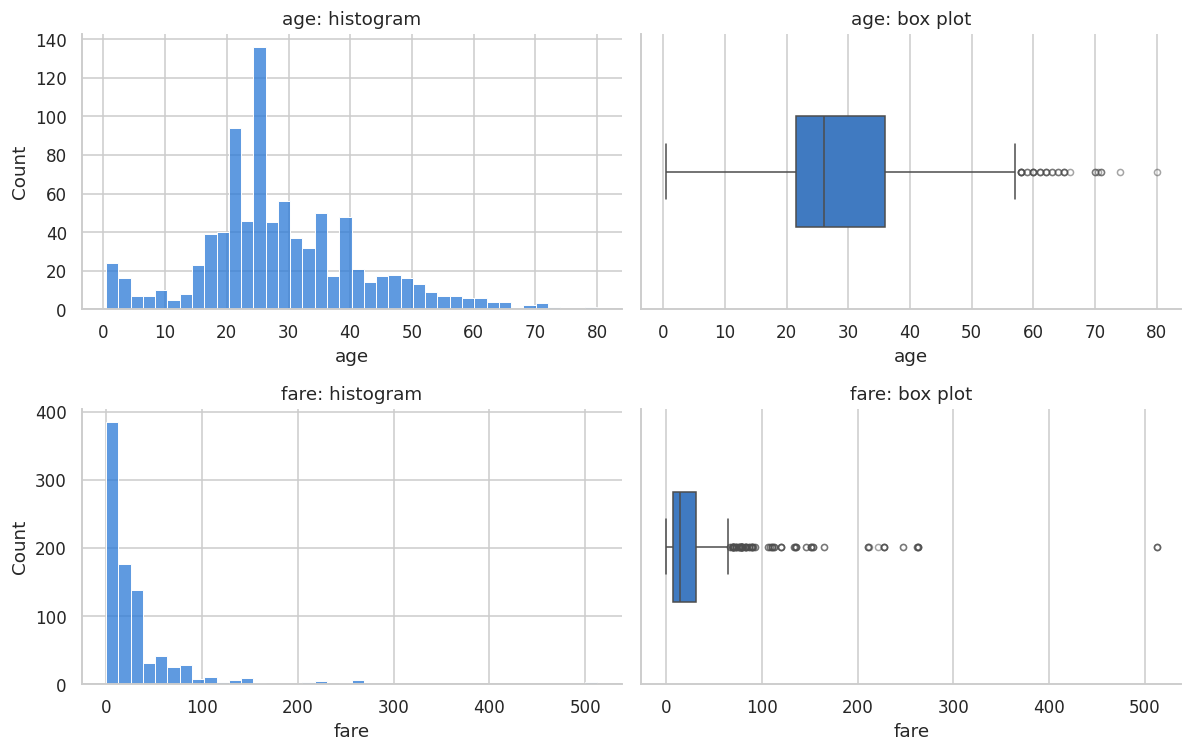

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row, col in enumerate(["age", "fare"]):
    sns.histplot(df[col], bins=40, ax=axes[row, 0], color=COLOR_SURVIVED, edgecolor="white")
    axes[row, 0].set_title(f"{col}: histogram")
    sns.boxplot(x=df[col], ax=axes[row, 1], color=COLOR_SURVIVED, width=0.4,
                flierprops=dict(marker="o", markersize=4, alpha=.5))
    axes[row, 1].set_title(f"{col}: box plot")
fig.tight_layout(); fig.savefig(FIG / "01_univariate_age_fare.png", bbox_inches="tight"); plt.show()

In [11]:
def iqr_outliers(s: pd.Series):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return dict(Q1=q1, Q3=q3, IQR=iqr, lower=lo, upper=hi, n_outliers=int(((s < lo) | (s > hi)).sum()))

# Reported both on the raw (pre-imputation) values and on the cleaned values, because median-imputation
# of age compresses its IQR and therefore changes the outlier count.
iqr_table = pd.DataFrame({
    "age (raw, non-null)": iqr_outliers(df_raw["age"].dropna()),
    "age (cleaned)": iqr_outliers(df["age"]),
    "fare (cleaned)": iqr_outliers(df["fare"]),
}).T.round(2)
iqr_table

,Q1,Q3,IQR,lower,upper,n_outliers
"age (raw, non-null)",20.12,38.0,17.88,-6.69,64.81,11.0
age (cleaned),21.50,36.0,14.50,-0.25,57.75,32.0
fare (cleaned),7.90,31.0,23.10,-26.76,65.66,114.0


In [12]:
fare_stats = pd.Series({"mean": df.fare.mean(), "median": df.fare.median(), "mode": df.fare.mode()[0],
                        "skewness": df.fare.skew()}).round(3)
fare_stats

mean        32.097
median      14.454
mode         8.050
skewness     4.801
dtype: float64

### Univariate findings

**IQR outlier counts** (outliers lie outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR]):

| Column | Q1 | Q3 | IQR | Bounds | Outliers |
|---|---|---|---|---|---|
| `age` (observed values only, before imputation) | 20.12 | 38.00 | 17.88 | [−6.69, 64.81] | **11** |
| `age` (cleaned, after group-median imputation) | 21.50 | 36.00 | 14.50 | [−0.25, 57.75] | **32** |
| `fare` (cleaned) | 7.90 | 31.00 | 23.10 | [−26.76, 65.66] | **114** |

`age` is reported twice on purpose. Imputing 177 values at just a few medians piles mass in the middle of the distribution. That narrows the IQR (17.88 → 14.50), so the same elderly passengers are flagged more often (11 → 32). The raw figure of **11** is the honest description of the age distribution. None of these outliers are errors: an 80-year-old passenger is real, so I keep them all. Of the 889 fares, **114** fall above the upper fence of 65.66. Those are real luxury tickets (up to 512.33), not errors, and they are kept. The model's `StandardScaler` handles the scale.

**Skewness of `fare`:** mean = **32.10**, median = **14.45**, mode = **8.05**. The ordering is **mode < median < mean**, which is the signature of a **right-skewed (positively skewed)** distribution. Most passengers paid a low 3rd-class fare, so the mode and median sit low, while a long tail of expensive 1st-class tickets drags the mean up to more than twice the median. The sample skewness of **+4.80** confirms it. `age` is close to symmetric by comparison: its histogram has a mild right tail and a small bump of infants.

## Task 4 — Bivariate analysis with boolean masking

In [13]:
def rate(mask):  # survival rate of the passengers selected by a boolean mask
    return round(df.loc[mask, "survived"].mean() * 100, 2)

by_sex = pd.Series({s: rate(df.sex == s) for s in ["female", "male"]}, name="survival_%")
by_class = pd.Series({f"class {c}": rate(df.pclass == c) for c in [1, 2, 3]}, name="survival_%")
by_sex_class = pd.DataFrame({s: {f"class {c}": rate((df.sex == s) & (df.pclass == c)) for c in [1, 2, 3]}
                             for s in ["female", "male"]})
print("(a) by sex\n", by_sex, "\n\n(b) by pclass\n", by_class, "\n\n(c) by sex & pclass\n", by_sex_class)

# A few |-combinations as extra evidence for 'women and children first'
print("\nwomen OR children (<16):", rate((df.sex == "female") | (df.age < 16)),
      "% | adult men (male & age>=16):", rate((df.sex == "male") & (df.age >= 16)), "%")

(a) by sex
 female    74.04
male      18.89
Name: survival_%, dtype: float64 

(b) by pclass
 class 1    62.62
class 2    47.28
class 3    24.24
Name: survival_%, dtype: float64 

(c) by sex & pclass
          female   male
class 1   96.74  36.89
class 2   92.11  15.74
class 3   50.00  13.54

women OR children (<16): 71.59 % | adult men (male & age>=16): 16.39 %


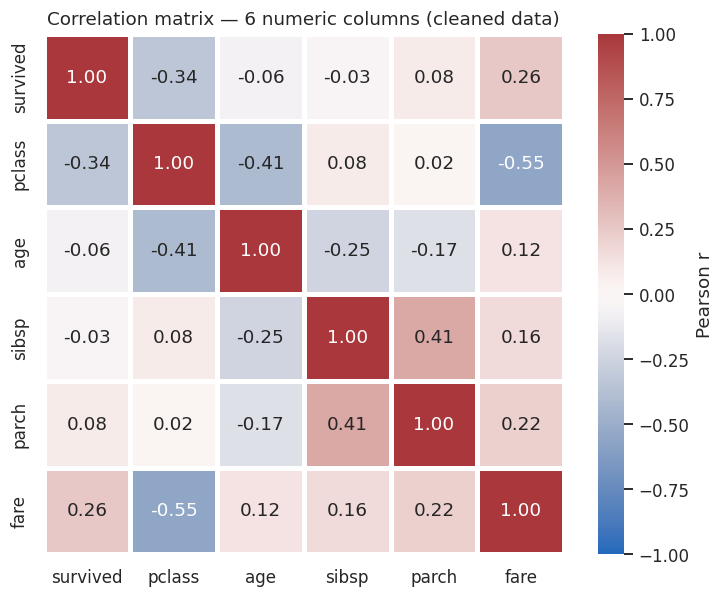

r  abs_r
pclass   fare   -0.548  0.548
sibsp    parch   0.415  0.415
pclass   age    -0.411  0.411
survived pclass -0.336  0.336
         fare    0.255  0.255

In [14]:
CORR_COLS = ["survived", "pclass", "age", "sibsp", "parch", "fare"]   # adult_male / alone deliberately excluded
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 5.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0, square=True,
            linewidths=2, linecolor="white", cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix — 6 numeric columns (cleaned data)")
fig.tight_layout(); fig.savefig(FIG / "02_correlation_heatmap.png", bbox_inches="tight"); plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
         .rename("r").to_frame().assign(abs_r=lambda d: d.r.abs()).sort_values("abs_r", ascending=False))
pairs.head(5).round(3)

### Bivariate findings

**Survival rates, computed with boolean masks:**
- **(a) By sex:** female **74.04%** vs male **18.89%**.
- **(b) By class:** 1st **62.62%**, 2nd **47.28%**, 3rd **24.24%**.
- **(c) By sex & class:** female 1st / 2nd / 3rd = **96.74% / 92.11% / 50.00%**; male 1st / 2nd / 3rd = **36.89% / 15.74% / 13.54%**.
- Extra `|` / `&` checks: `(sex == female) | (age < 16)` survived at **71.59%**, `(sex == male) & (age >= 16)` at only **16.39%**.

**Two strongest correlations**, ranked by |r| over all 15 off-diagonal pairs of the 6×6 matrix (`survived, pclass, age, sibsp, parch, fare`; `adult_male` and `alone` excluded):

1. **`pclass` ↔ `fare`: r = −0.548.** The strongest pair. A higher class *number* means a cheaper ticket, so 3rd class pays the least. The sign is negative only because class 1 is the "top" class. The relationship is structural (ticket price was set by class). That is also why a model gets partly redundant information from the two columns.
2. **`sibsp` ↔ `parch`: r = +0.415.** Passengers travelling with siblings or a spouse also tend to travel with parents or children, because families board together. Both columns measure "family on board", which is why Chart 4 combines them into `family_size`.

Third place is `pclass` ↔ `age` (r = −0.411; older passengers were in better classes). It is a close third, and group-median imputation reinforces it slightly. Among correlations with the target, `survived` ↔ `pclass` is the strongest (r = −0.336), followed by `survived` ↔ `fare` (+0.255). Sex does not appear in this matrix only because it is not numeric. As shown above, it is the single strongest driver of survival.

## Task 5 — Multivariate data story: who survived, and why?

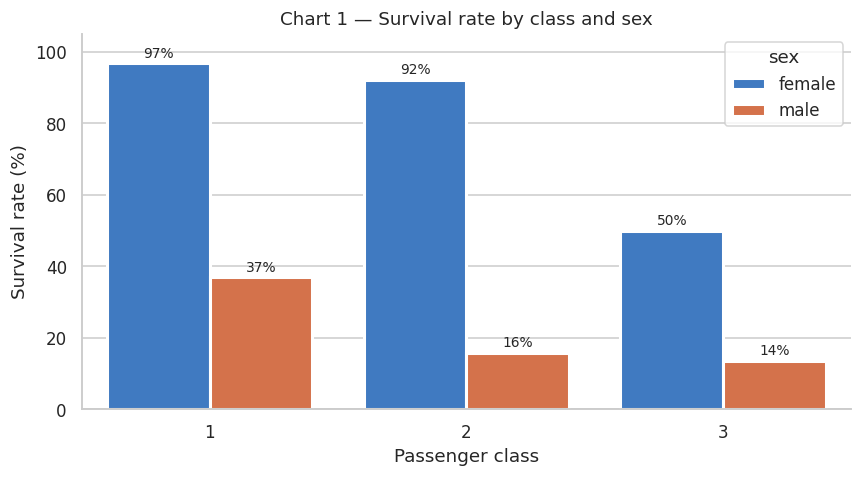

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sr = df.groupby(["pclass", "sex"])["survived"].mean().mul(100).reset_index()
sns.barplot(data=sr, x="pclass", y="survived", hue="sex", palette={"female": COLOR_SURVIVED, "male": COLOR_DIED},
            ax=ax, edgecolor="white", linewidth=2)
for c in ax.containers: ax.bar_label(c, fmt="%.0f%%", padding=2, fontsize=9)
ax.set(xlabel="Passenger class", ylabel="Survival rate (%)", ylim=(0, 105),
       title="Chart 1 — Survival rate by class and sex")
fig.tight_layout(); fig.savefig(FIG / "03_story_class_sex.png", bbox_inches="tight"); plt.show()

**Chart 1 interpretation.** Sex and class together explain most of who survived. Nearly every woman in 1st and 2nd class survived (97% and 92%), but only half of 3rd-class women did. Men had worse odds in every class, dropping from 37% in 1st class to around 14–16% in 2nd and 3rd. The "women first" rule was applied strongly, but it was weakened by class: a 3rd-class woman had lower odds than a 1st-class woman, though still better odds than any man.

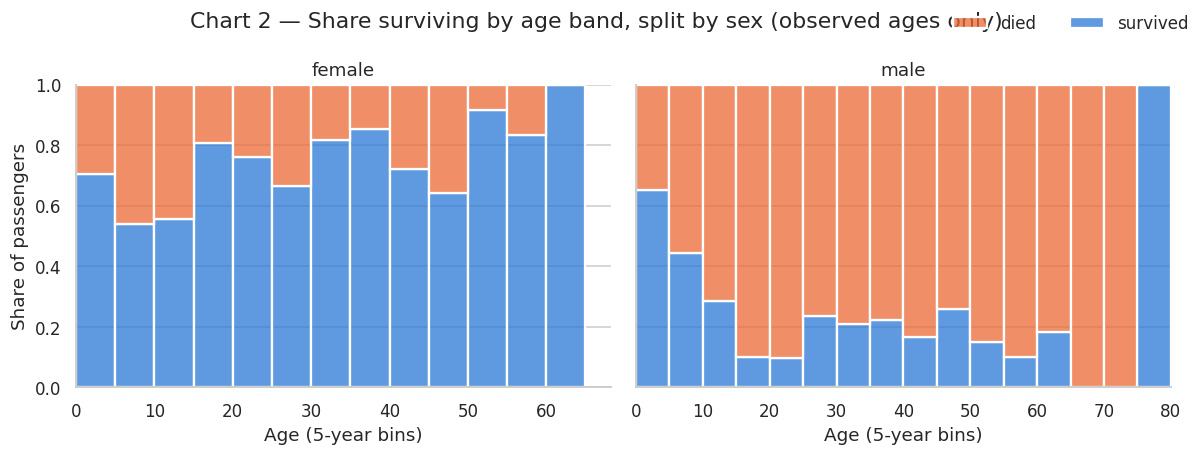

sex    female  male
age                
0-12     59.4  56.8
13-18    75.0   8.8
19-40    78.6  18.2
41-60    75.6  19.3
61-80   100.0  10.5


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, s in zip(axes, ["female", "male"]):
    sub = df_raw[(df_raw.sex == s) & df_raw.age.notna()]    # raw ages: imputed values would create a fake spike
    sns.histplot(data=sub, x="age", hue="survived", bins=range(0, 85, 5), multiple="fill",
                 palette=SURVIVAL_PALETTE, ax=ax, edgecolor="white", linewidth=1.5, legend=(s == "male"))
    ax.set(title=f"{s}", xlabel="Age (5-year bins)", ylabel="Share of passengers")
handles = axes[1].get_legend().legend_handles; axes[1].get_legend().remove()
fig.legend(handles, ["died", "survived"], loc="upper right", ncol=2, frameon=False)
fig.suptitle("Chart 2 — Share surviving by age band, split by sex (observed ages only)")
fig.tight_layout(); fig.savefig(FIG / "04_story_age_sex.png", bbox_inches="tight"); plt.show()

bands = pd.cut(df_raw.age, [0, 12, 18, 40, 60, 80], labels=["0-12", "13-18", "19-40", "41-60", "61-80"])
print((df_raw.groupby([bands, "sex"], observed=True)["survived"].mean().mul(100).round(1).unstack()))

**Chart 2 interpretation.** This chart uses observed ages only, so imputed values cannot create a false spike. Age mattered mainly for boys. Boys aged 0–12 survived at 56.8%, almost the same as girls (59.4%), but for males aged 13–18 survival falls to 8.8% and stays around 10–19% for every older band. Among females, survival stays high (roughly 60–100%) at every age. So "children first" in practice meant young boys were saved alongside women, and once a boy was treated as a man his odds collapsed.

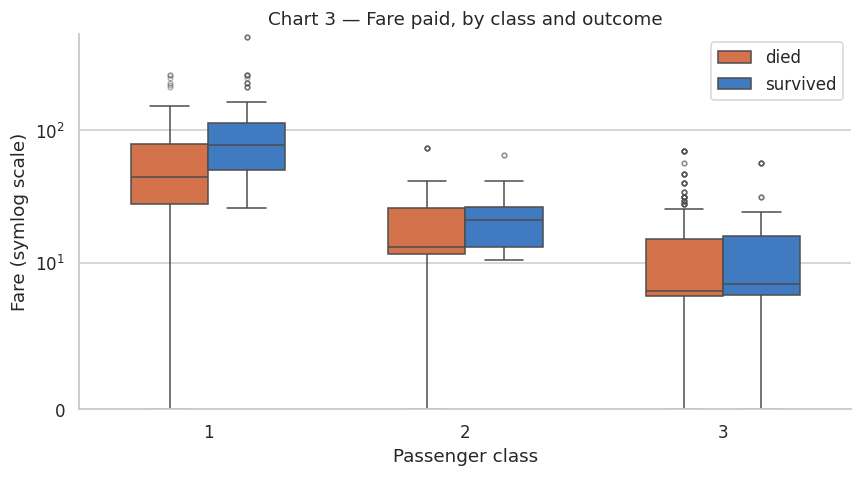

survived   died  survived
pclass                   
1         44.75     77.34
2         13.00     21.00
3          8.05      8.52


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="pclass", y="fare", hue="survived", palette=SURVIVAL_PALETTE, ax=ax, width=.6,
            flierprops=dict(marker="o", markersize=3, alpha=.4))
ax.set_yscale("symlog", linthresh=10); ax.set_ylim(bottom=0)
ax.set(xlabel="Passenger class", ylabel="Fare (symlog scale)", title="Chart 3 — Fare paid, by class and outcome")
h, _ = ax.get_legend_handles_labels(); ax.legend(h, ["died", "survived"], title="")
fig.tight_layout(); fig.savefig(FIG / "05_story_fare_class.png", bbox_inches="tight"); plt.show()
print(df.groupby(["pclass", "survived"])["fare"].median().unstack().rename(columns={0: "died", 1: "survived"}).round(2))

**Chart 3 interpretation.** Within 1st class, survivors paid noticeably more than those who died (median fare 77.34 vs 44.75), and 2nd class shows the same pattern (21.00 vs 13.00). A higher fare likely meant a better cabin higher up and closer to the boat deck. In 3rd class the two medians are almost identical (8.52 vs 8.05), so paying more within steerage did not buy a better chance. Fare adds information beyond class mainly *inside* the upper classes. The log-style y-axis keeps the 512-pound outliers from flattening everything else.

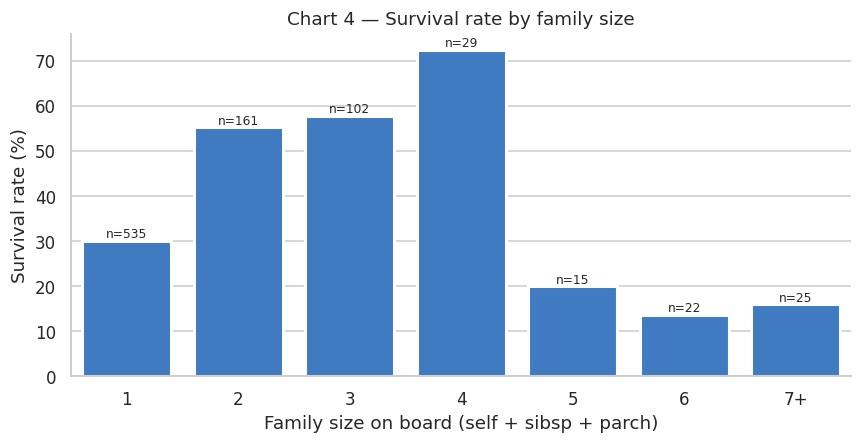

family  survival   n
     1      30.1 535
     2      55.3 161
     3      57.8 102
     4      72.4  29
     5      20.0  15
     6      13.6  22
    7+      16.0  25


In [18]:
df["family_size"] = df.sibsp + df.parch + 1
fam = df.assign(family=df.family_size.clip(upper=7).astype(str).replace("7", "7+"))
fs = fam.groupby("family").agg(survival=("survived", "mean"), n=("survived", "size")).reset_index()
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=fs, x="family", y=fs.survival * 100, color=COLOR_SURVIVED, ax=ax, edgecolor="white", linewidth=2)
for p, n in zip(ax.patches, fs.n):
    ax.annotate(f"n={n}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=8)
ax.set(xlabel="Family size on board (self + sibsp + parch)", ylabel="Survival rate (%)",
       title="Chart 4 — Survival rate by family size")
fig.tight_layout(); fig.savefig(FIG / "06_story_family_size.png", bbox_inches="tight"); plt.show()
print(fs.assign(survival=lambda d: (d.survival * 100).round(1)).to_string(index=False))

**Chart 4 interpretation.** Survival is not monotonic in family size. Passengers travelling alone survived at only 30.1% (n = 535, most of them 3rd-class men). Small families of 2–4 did best, peaking at 72.4% for families of four. Large families of 5 or more fell to 13.6–20.0%, probably because keeping a big group together in the evacuation was hard, and these groups were mostly in 3rd class. This non-linear pattern is one reason tree-based models can outperform a linear model on this data.

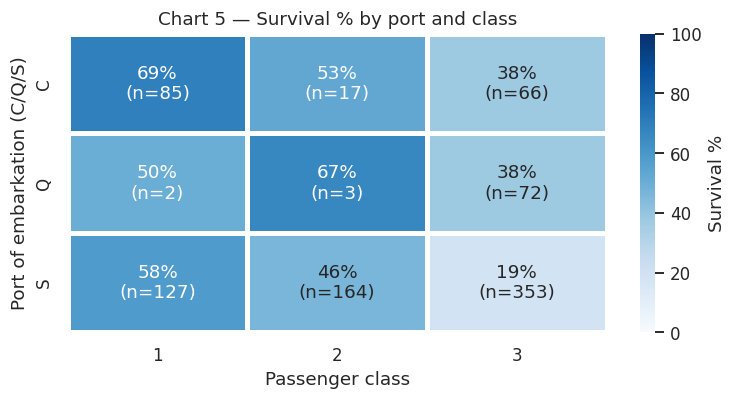

pclass        1      2      3
embarked                     
C         0.506  0.101  0.393
Q         0.026  0.039  0.935
S         0.197  0.255  0.548


In [19]:
emb = df.pivot_table(index="embarked", columns="pclass", values="survived", aggfunc="mean").mul(100)
cnt = df.pivot_table(index="embarked", columns="pclass", values="survived", aggfunc="size")
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.heatmap(emb, annot=emb.round(0).astype(int).astype(str) + "%\n(n=" + cnt.astype(str) + ")", fmt="",
            cmap="Blues", vmin=0, vmax=100, linewidths=2, linecolor="white", cbar_kws={"label": "Survival %"}, ax=ax)
ax.set(xlabel="Passenger class", ylabel="Port of embarkation (C/Q/S)",
       title="Chart 5 — Survival % by port and class")
fig.tight_layout(); fig.savefig(FIG / "07_story_port_class.png", bbox_inches="tight"); plt.show()
print(pd.crosstab(df.embarked, df.pclass, normalize="index").round(3))

**Chart 5 interpretation.** Cherbourg (C) passengers survived at 55.4% overall, against 38.9% for Queenstown (Q) and 33.7% for Southampton (S). The heatmap shows this is mostly class composition, not the port itself: 50.6% of Cherbourg boarders were in 1st class, against 93.5% of Queenstown boarders in 3rd class. Within 3rd class, Southampton is still clearly the worst (19%, n = 353), consistent with its many lone adult men. Port therefore acts mostly as a proxy for class and wealth. The Q/1st and Q/2nd cells have n = 2 and n = 3, so they carry no meaningful information.

### The data story in one paragraph
Survival on the Titanic followed a clear order: **sex first, then class, then age and family context.** Women survived at 74% and men at 19% (Chart 1). Class then split each group: a 1st-class woman almost always survived and a 3rd-class man almost never did. Among children, boys were saved almost as often as girls, but once past about 12 a male's odds were no better than an adult man's (Chart 2). Money helped within the upper classes, where survivors paid higher fares (Chart 3). Travelling alone or in a very large group hurt, while small families did best (Chart 4). Port of embarkation looks important but mostly reflects who boarded where (Chart 5). **The predictive features to carry into modelling are therefore `sex`, `pclass`, `age`, `fare`, and family size (`sibsp`/`parch`), with `embarked` as a weak proxy.**

## Task 6 — Exploratory z-score standardisation check (EDA only, not used for modelling)

In [20]:
z = df[["age", "fare"]].copy()
z_manual = (z - z.mean()) / z.std(ddof=0)                  # z = (x - mean) / std
z_sklearn = pd.DataFrame(StandardScaler().fit_transform(z), columns=z.columns)
assert np.allclose(z_manual, z_sklearn)

def describe(frame):  # population std (ddof=0), the same definition StandardScaler uses
    return pd.DataFrame({"mean": frame.mean(), "std (ddof=0)": frame.std(ddof=0),
                         "min": frame.min(), "max": frame.max()}).T
summary = pd.concat({"before": describe(z), "after (z-score)": describe(z_manual)}, axis=1).round(4)
summary

before           after (z-score)        
                  age      fare             age    fare
mean          29.0654   32.0967          0.0000  0.0000
std (ddof=0)  13.2627   49.6695          1.0000  1.0000
min            0.4200    0.0000         -2.1598 -0.6462
max           80.0000  512.3292          3.8404  9.6686

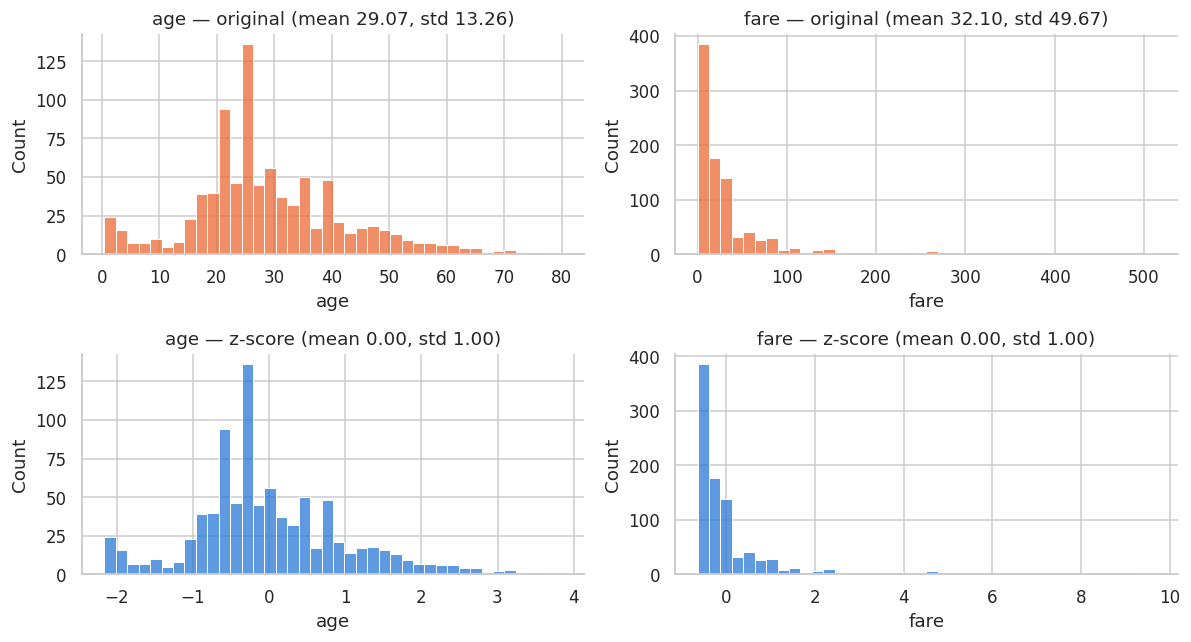

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for i, col in enumerate(["age", "fare"]):
    sns.histplot(z[col], bins=40, ax=axes[0, i], color=COLOR_DIED, edgecolor="white")
    axes[0, i].set_title(f"{col} — original (mean {z[col].mean():.2f}, std {z[col].std(ddof=0):.2f})")
    sns.histplot(z_manual[col], bins=40, ax=axes[1, i], color=COLOR_SURVIVED, edgecolor="white")
    axes[1, i].set_title(f"{col} — z-score (mean {z_manual[col].mean():.2f}, std {z_manual[col].std(ddof=0):.2f})")
fig.tight_layout(); fig.savefig(FIG / "08_zscore_before_after.png", bbox_inches="tight"); plt.show()

**Standardisation check.** After z = (x − mean) / std, both `age` and `fare` have mean **0.0000** and population std **1.0000**, matching `StandardScaler` exactly (asserted with `np.allclose`). The histograms have **identical shapes before and after**: z-scoring is a linear shift-and-rescale, so `fare` is still heavily right-skewed (its max is now +9.67 SDs) and `age` still has its imputation spike. Standardisation fixes scale, not skew. Because this check is fitted on the full cleaned data, it is **EDA only**. `02_modeling.ipynb` fits its own `StandardScaler` on the training split alone.